# Ridge — entrenamiento y batería de pruebas de overfitting

**Modelo:** `Ridge` (regresión lineal con regularización L2), dentro de un
`Pipeline` con `StandardScaler` — Ridge es sensible a la escala de las
features, así que sin estandarizar, las variables con rangos numéricos más
grandes dominarían el coeficiente de forma artificial.

**Por qué Ridge es un buen punto de comparación:** en la comparación
inicial de los 5 modelos clásicos, Ridge tuvo el RMSE prácticamente
empatado con los modelos de árboles pero con la brecha de overfitting más
cercana a cero. Este notebook corre la misma batería de 5 pruebas que se
usó para GradientBoosting, para confirmar (no asumir) que ese buen
comportamiento se sostiene bajo un análisis más profundo.

**A diferencia de los modelos de árboles, Ridge solo tiene un hiperparámetro
de regularización (`alpha`)** — por eso la Prueba 3 aquí es una curva de
validación contra `alpha`, no contra `n_estimators`.

**Entrada:** `GET /features/history` del Data Service (mismo contrato que
los notebooks anteriores — RNF17).


In [16]:
import warnings
warnings.filterwarnings("ignore")

import requests
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


## 0. Carga de datos vía la API del Data Service

In [17]:
# Bootstrap: pide la data al Data Service por HTTP (tal como lo hará el
# ML Service en producción) en vez de importar DataPipeline o leer un CSV
# local. Esto valida de una vez que el contrato de la API es el correcto.
DATA_SERVICE_URL = "http://localhost:8000"  # ajusta si tu Data Service corre en otro host/puerto
PAIR_CODE = "SP500_VIX"

EXPECTED_FEATURE_COLUMNS = [
    "main_log_return", "main_log_range", "main_body_log",
    "main_upper_wick_log", "main_lower_wick_log",
    "main_vol_5d", "main_vol_10d",
    "vol_idx_log_close", "vol_idx_log_range", "vol_idx_log_return",
    "day_of_week", "target_range_next_day",
]

response = requests.get(f"{DATA_SERVICE_URL}/features/history", params={"pair_code": PAIR_CODE}, timeout=30)
response.raise_for_status()
rows = response.json()
assert rows, f"El Data Service no devolvió filas para {PAIR_CODE}."

df = pd.DataFrame(rows)
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)

missing = set(EXPECTED_FEATURE_COLUMNS) - set(df.columns)
assert not missing, f"Faltan columnas esperadas del esquema: {missing}"

versions = df["schema_version"].unique()
assert len(versions) == 1, (
    f"Se mezclaron filas de más de una versión de esquema: {versions} — "
    "RNF12: no se debe modelar sobre un esquema inconsistente."
)

print(f"Par:                {PAIR_CODE}")
print(f"Filas:              {len(df)}")
print(f"Rango de fechas:    {df['date'].min().date()} → {df['date'].max().date()}")
print(f"Versión de esquema: {versions[0]}")

df = df.set_index("date")[EXPECTED_FEATURE_COLUMNS]

print(f"Columnas de trabajo ({len(df.columns)}): {list(df.columns)}")
df.head()


Par:                SP500_VIX
Filas:              5411
Rango de fechas:    2005-01-18 → 2026-07-22
Versión de esquema: v1
Columnas de trabajo (12): ['main_log_return', 'main_log_range', 'main_body_log', 'main_upper_wick_log', 'main_lower_wick_log', 'main_vol_5d', 'main_vol_10d', 'vol_idx_log_close', 'vol_idx_log_range', 'vol_idx_log_return', 'day_of_week', 'target_range_next_day']


,main_log_return,main_log_range,main_body_log,main_upper_wick_log,main_lower_wick_log,main_vol_5d,main_vol_10d,vol_idx_log_close,vol_idx_log_range,vol_idx_log_return,day_of_week,target_range_next_day
date,,,,,,,,,,,,
2005-01-18,0.009628,0.013367,0.009628,0.000000,0.003738,0.007942,0.006923,2.523326,0.066822,0.003213,1,0.009721
2005-01-19,-0.009535,0.009721,-0.009535,0.000000,0.000186,0.008803,0.006550,2.578701,0.062472,0.055375,2,0.009508
2005-01-20,-0.007813,0.009508,-0.007813,0.000000,0.001694,0.009138,0.006911,2.626840,0.060625,0.048140,3,0.009909
2005-01-21,-0.006435,0.009909,-0.006435,0.003431,0.000043,0.008783,0.006953,2.664447,0.076132,0.037606,4,0.007943
2005-01-24,-0.003534,0.007943,-0.003534,0.004409,0.000000,0.007681,0.006976,2.684440,0.040116,0.019994,0,0.009025


## 1. Configuración del modelo e hiperparámetros

In [18]:
HYPERPARAMS = {
    "alpha": 10.0,
    "random_state": RANDOM_STATE,
}

FEATURE_COLS = [c for c in EXPECTED_FEATURE_COLUMNS if c != "target_range_next_day"]

def build_model(**overrides):
    """Crea una instancia nueva del pipeline Ridge (con StandardScaler)
    con HYPERPARAMS, permitiendo sobrescribir puntualmente (usado en la
    curva de validación para variar alpha sin tocar el resto)."""
    params = {**HYPERPARAMS, **overrides}
    return make_pipeline(StandardScaler(), Ridge(**params))

print("Hiperparámetros:", HYPERPARAMS)


Hiperparámetros: {'alpha': 10.0, 'random_state': 42}


## 2. Split cronológico train/test y entrenamiento base

División 80/20 **sin mezclar** (nunca `shuffle=True` en series de tiempo).


In [19]:
X = df[FEATURE_COLS].values
y = df["target_range_next_day"].values

split_idx = int(len(df) * 0.8)
X_train, X_test = X[:split_idx], X[split_idx:]
y_train, y_test = y[:split_idx], y[split_idx:]

train_dates = df.index[:split_idx]
test_dates = df.index[split_idx:]

print(f"Train: {len(X_train)} filas  ({train_dates.min().date()} -> {train_dates.max().date()})")
print(f"Test:  {len(X_test)} filas  ({test_dates.min().date()} -> {test_dates.max().date()})")

modelo = build_model()
modelo.fit(X_train, y_train)
print("\nModelo entrenado.")


Train: 4328 filas  (2005-01-18 -> 2022-03-25)
Test:  1083 filas  (2022-03-28 -> 2026-07-22)

Modelo entrenado.


## Prueba 1 — RMSE, MAE y R² en train vs. test

**Qué se busca:** una brecha entre train y test en más de una métrica a la
vez. RMSE castiga errores grandes más que MAE; si una diverge y la otra no,
el modelo falla de forma distinta en errores típicos vs. extremos.

**Señal de overfitting:** `RMSE_test`/`MAE_test` notablemente peores que
train, y `R²_test` mucho menor que `R²_train`.


In [20]:
def metricas(y_true, y_pred):
    return {
        "rmse": np.sqrt(mean_squared_error(y_true, y_pred)),
        "mae": mean_absolute_error(y_true, y_pred),
        "r2": r2_score(y_true, y_pred),
    }

pred_train = modelo.predict(X_train)
pred_test = modelo.predict(X_test)

m_train = metricas(y_train, pred_train)
m_test = metricas(y_test, pred_test)

prueba1 = pd.DataFrame([
    {"conjunto": "Train", **m_train},
    {"conjunto": "Test", **m_test},
    {"conjunto": "Gap (test - train)",
     "rmse": m_test["rmse"] - m_train["rmse"],
     "mae": m_test["mae"] - m_train["mae"],
     "r2": m_test["r2"] - m_train["r2"]},
])
prueba1


,conjunto,rmse,mae,r2
0,Train,0.006182,0.004070,0.638498
1,Test,0.005742,0.003907,0.435731
2,Gap (test - train),-0.000440,-0.000162,-0.202767


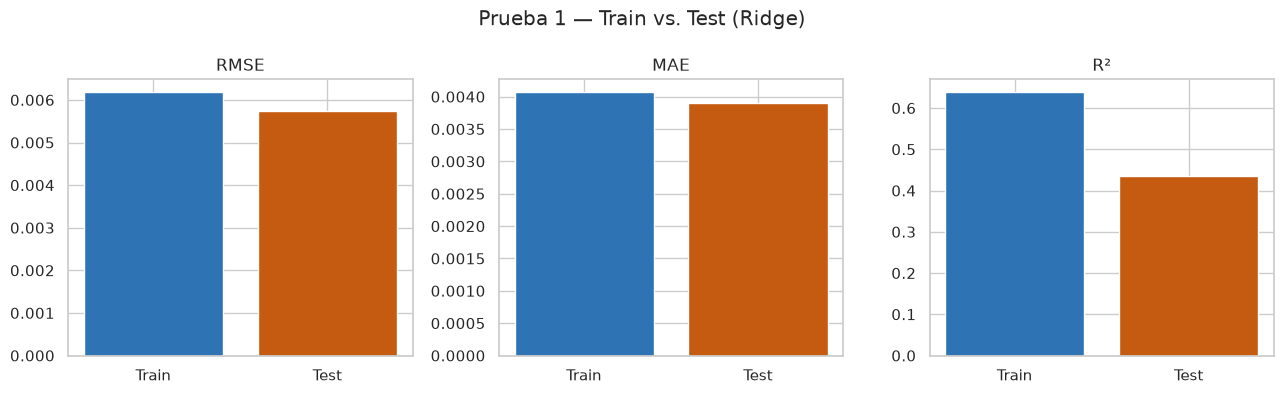

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4))
for ax, metric, label in zip(axes, ["rmse", "mae", "r2"], ["RMSE", "MAE", "R²"]):
    ax.bar(["Train", "Test"], [m_train[metric], m_test[metric]], color=["#2E74B5", "#C55A11"])
    ax.set_title(label)
plt.suptitle("Prueba 1 — Train vs. Test (Ridge)")
plt.tight_layout()
plt.show()


## Prueba 2 — Desempeño por régimen de volatilidad (normal vs. crisis)

**Qué se busca:** un RMSE agregado bueno puede esconder que el modelo
falla justo en los períodos de crisis (la minoría de las filas, pero el
motivo por el que existe este modelo). Los umbrales se calculan **solo con
el train**, para no filtrar la distribución del test hacia la definición
de las categorías.

**Señal de overfitting:** el gap train→test es mucho peor dentro de
"Crisis" que dentro de "Normal".


In [22]:
CRISIS_QUANTILE = 0.75

umbral_crisis = np.quantile(df["vol_idx_log_close"].values[:split_idx], CRISIS_QUANTILE)
print(f"Umbral de régimen (calculado solo con train): vol_idx_log_close >= {umbral_crisis:.4f} -> Crisis")

def etiquetar_regimen(vol_idx_log_close, umbral):
    return np.where(vol_idx_log_close >= umbral, "Crisis", "Normal")

regimen_train = etiquetar_regimen(df["vol_idx_log_close"].values[:split_idx], umbral_crisis)
regimen_test = etiquetar_regimen(df["vol_idx_log_close"].values[split_idx:], umbral_crisis)

def rmse_mae_por_regimen(y_true, y_pred, regimen, conjunto):
    out = []
    for r in ["Normal", "Crisis"]:
        mask = regimen == r
        if mask.sum() == 0:
            continue
        out.append({
            "conjunto": conjunto, "regimen": r, "n": int(mask.sum()),
            "rmse": np.sqrt(mean_squared_error(y_true[mask], y_pred[mask])),
            "mae": mean_absolute_error(y_true[mask], y_pred[mask]),
        })
    return out

prueba2 = pd.DataFrame(
    rmse_mae_por_regimen(y_train, pred_train, regimen_train, "Train") +
    rmse_mae_por_regimen(y_test, pred_test, regimen_test, "Test")
)
prueba2


Umbral de régimen (calculado solo con train): vol_idx_log_close >= 3.1040 -> Crisis


,conjunto,regimen,n,rmse,mae
0,Train,Normal,3246,0.004210,0.003080
1,Train,Crisis,1082,0.009984,0.007039
2,Test,Normal,851,0.004452,0.003263
3,Test,Crisis,232,0.009011,0.006272


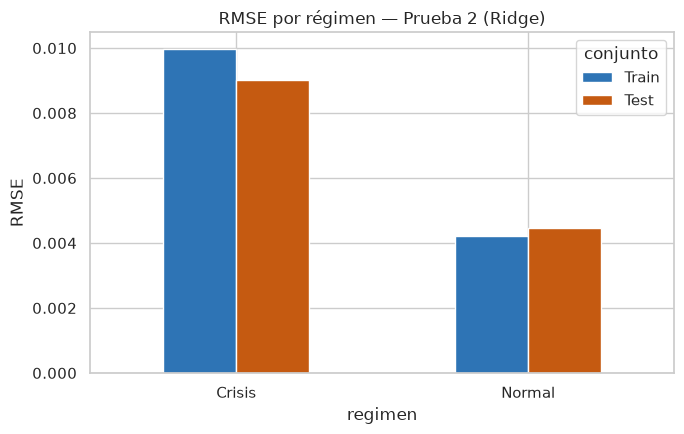


Gap (Test - Train) por régimen:
regimen
Crisis   -0.000974
Normal    0.000242
Name: gap, dtype: float64


In [23]:
pivot_rmse = prueba2.pivot(index="regimen", columns="conjunto", values="rmse")
pivot_rmse["gap"] = pivot_rmse["Test"] - pivot_rmse["Train"]

fig, ax = plt.subplots(figsize=(7, 4.5))
pivot_rmse[["Train", "Test"]].plot(kind="bar", ax=ax, color=["#2E74B5", "#C55A11"])
ax.set_title("RMSE por régimen — Prueba 2 (Ridge)")
ax.set_ylabel("RMSE")
ax.tick_params(axis="x", rotation=0)
plt.tight_layout()
plt.show()

print("\nGap (Test - Train) por régimen:")
print(pivot_rmse["gap"])


## Prueba 3 — Curva de validación vs. `alpha`

**Qué se busca:** a diferencia de `n_estimators` en boosting (donde más
árboles puede sobreajustar), en Ridge la dirección es la contraria: `alpha`
**bajo** = poca regularización = más riesgo de overfitting; `alpha` **alto**
= mucha regularización = el modelo se vuelve demasiado simple y empieza a
fallar también en train (underfitting).

**Señal de overfitting:** con `alpha` bajo, el train RMSE es notablemente
mejor que el test RMSE. El punto óptimo es donde el test RMSE toca su
mínimo — no necesariamente donde el train RMSE es más bajo.


In [24]:
alphas = [0.001, 0.01, 0.1, 0.5, 1.0, 5.0, 10.0, 50.0, 100.0, 500.0, 1000.0]
curva = []
for a in alphas:
    m = build_model(alpha=a)
    m.fit(X_train, y_train)
    curva.append({
        "alpha": a,
        "rmse_train": np.sqrt(mean_squared_error(y_train, m.predict(X_train))),
        "rmse_test": np.sqrt(mean_squared_error(y_test, m.predict(X_test))),
    })
curva_df = pd.DataFrame(curva)
curva_df


,alpha,rmse_train,rmse_test
0,0.001,0.006182,0.005743
1,0.010,0.006182,0.005743
2,0.100,0.006182,0.005743
3,0.500,0.006182,0.005743
4,1.000,0.006182,0.005743
5,5.000,0.006182,0.005742
6,10.000,0.006182,0.005742
7,50.000,0.006182,0.005738
8,100.000,0.006184,0.005735
9,500.000,0.006198,0.005729


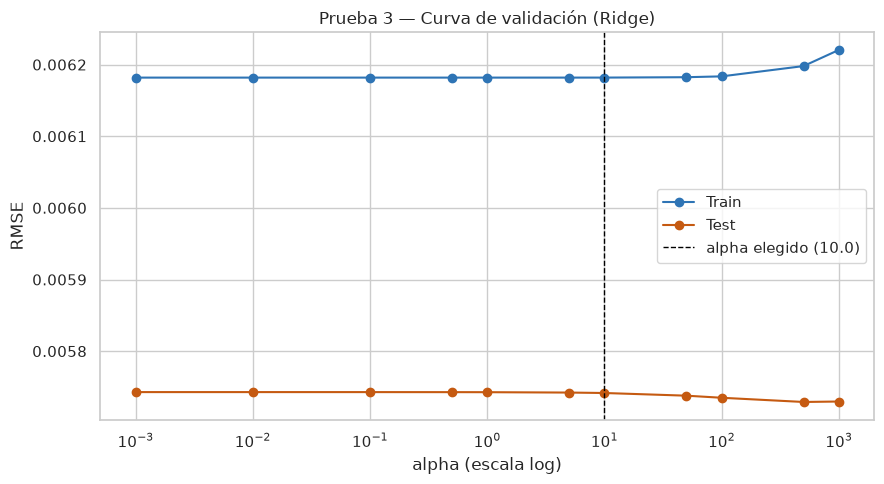

alpha con menor RMSE de test en esta curva: 500.0
alpha elegido: 10.0


In [25]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(curva_df["alpha"], curva_df["rmse_train"], label="Train", marker="o", color="#2E74B5")
ax.plot(curva_df["alpha"], curva_df["rmse_test"], label="Test", marker="o", color="#C55A11")
ax.axvline(HYPERPARAMS["alpha"], color="black", linestyle="--", linewidth=1,
           label=f"alpha elegido ({HYPERPARAMS['alpha']})")
ax.set_xscale("log")
ax.set_xlabel("alpha (escala log)")
ax.set_ylabel("RMSE")
ax.set_title("Prueba 3 — Curva de validación (Ridge)")
ax.legend()
plt.tight_layout()
plt.show()

optimo = curva_df.loc[curva_df["rmse_test"].idxmin(), "alpha"]
print(f"alpha con menor RMSE de test en esta curva: {optimo}")
print(f"alpha elegido: {HYPERPARAMS['alpha']}")


## Prueba 4 — Estabilidad entre folds (Walk-Forward Validation)

**Qué se busca:** que el resultado de la Prueba 1 no dependa de dónde cayó
la frontera train/test por casualidad. Walk-Forward con ventana expansiva
repite el entrenamiento en 5 ventanas temporales distintas.

**Señal de overfitting:** brecha consistentemente positiva y de magnitud
similar en la mayoría de los folds — no solo en uno.


In [26]:
def walk_forward_validate_ridge(X, y, feature_names, n_splits=5, min_train_frac=0.5):
    """Walk-Forward Validation con ventana expansiva para Ridge.

    Captura ademas los coeficientes (en valor absoluto) de cada fold, para
    la Prueba 5 -- sin tener que reentrenar de nuevo.
    """
    n = len(X)
    min_train = int(n * min_train_frac)
    fold_size = (n - min_train) // n_splits

    metric_rows = []
    coef_rows = []
    for fold in range(1, n_splits + 1):
        train_end = min_train + fold_size * (fold - 1)
        test_end = min_train + fold_size * fold if fold < n_splits else n
        if test_end <= train_end:
            continue

        X_tr, y_tr = X[:train_end], y[:train_end]
        X_te, y_te = X[train_end:test_end], y[train_end:test_end]

        model = build_model()
        model.fit(X_tr, y_tr)

        train_pred, test_pred = model.predict(X_tr), model.predict(X_te)
        metric_rows.append({
            "fold": fold, "n_train": len(y_tr), "n_test": len(y_te),
            "train_rmse": np.sqrt(mean_squared_error(y_tr, train_pred)),
            "test_rmse": np.sqrt(mean_squared_error(y_te, test_pred)),
            "train_mae": mean_absolute_error(y_tr, train_pred),
            "test_mae": mean_absolute_error(y_te, test_pred),
        })
        coefs = np.abs(model.named_steps["ridge"].coef_)
        coef_rows.append({"fold": fold, **dict(zip(feature_names, coefs))})

    return pd.DataFrame(metric_rows), pd.DataFrame(coef_rows)


fold_metrics, fold_coefs = walk_forward_validate_ridge(X, y, FEATURE_COLS, n_splits=5)
fold_metrics["brecha_rmse"] = fold_metrics["test_rmse"] - fold_metrics["train_rmse"]
fold_metrics


,fold,n_train,n_test,train_rmse,test_rmse,train_mae,test_mae,brecha_rmse
0,1,2705,541,0.006611,0.003709,0.004334,0.002652,-0.002902
1,2,3246,541,0.006220,0.005322,0.004039,0.003672,-0.000898
2,3,3787,541,0.006097,0.006920,0.003978,0.005170,0.000823
3,4,4328,541,0.006182,0.005611,0.004070,0.004032,-0.000571
4,5,4869,542,0.006118,0.005890,0.004054,0.003786,-0.000228


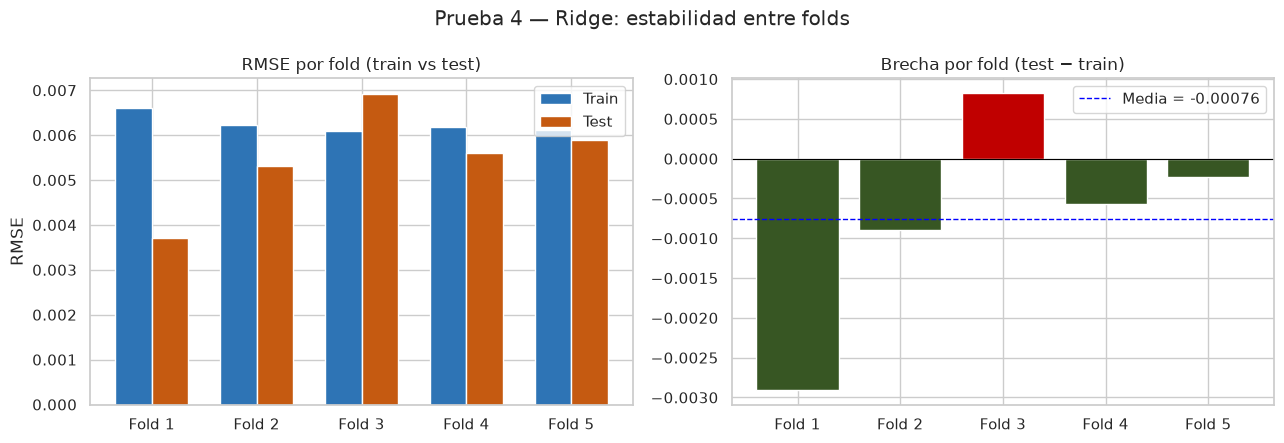

In [27]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

width = 0.35
x = np.arange(len(fold_metrics))
axes[0].bar(x - width/2, fold_metrics["train_rmse"], width, label="Train", color="#2E74B5")
axes[0].bar(x + width/2, fold_metrics["test_rmse"], width, label="Test", color="#C55A11")
axes[0].set_xticks(x); axes[0].set_xticklabels([f"Fold {f}" for f in fold_metrics["fold"]])
axes[0].set_ylabel("RMSE"); axes[0].set_title("RMSE por fold (train vs test)"); axes[0].legend()

colors = ["#C00000" if v > 0 else "#375623" for v in fold_metrics["brecha_rmse"]]
axes[1].bar([f"Fold {f}" for f in fold_metrics["fold"]], fold_metrics["brecha_rmse"], color=colors)
axes[1].axhline(0, color="black", linewidth=0.8)
media = fold_metrics["brecha_rmse"].mean()
axes[1].axhline(media, color="blue", linestyle="--", linewidth=1, label=f"Media = {media:.5f}")
axes[1].set_title("Brecha por fold (test − train)"); axes[1].legend()

plt.suptitle("Prueba 4 — Ridge: estabilidad entre folds")
plt.tight_layout()
plt.show()


## Prueba 5 — Estabilidad de los coeficientes entre folds

**Qué se busca:** el equivalente de "importancia de variables" para un
modelo lineal es la magnitud de sus coeficientes. Si el peso que Ridge le
da a una variable cambia mucho de un fold a otro, el modelo no está
capturando una relación estable.

**Señal de overfitting:** variables con coeficiente alto en un fold y casi
nulo en el siguiente (coeficiente de variación alto).


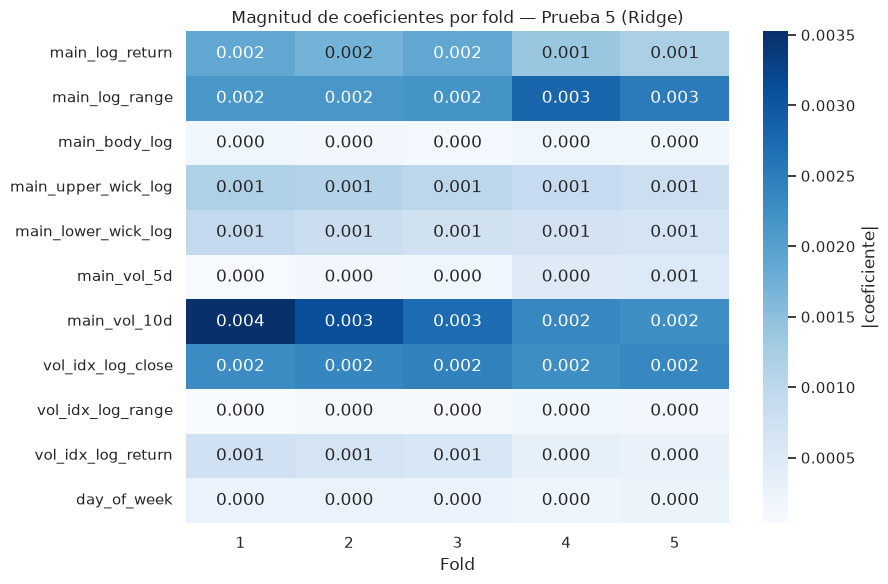

In [28]:
coef_matrix = fold_coefs.set_index("fold")[FEATURE_COLS]

fig, ax = plt.subplots(figsize=(9, 6))
sns.heatmap(coef_matrix.T, annot=True, fmt=".3f", cmap="Blues",
            cbar_kws={"label": "|coeficiente|"}, ax=ax)
ax.set_title("Magnitud de coeficientes por fold — Prueba 5 (Ridge)")
ax.set_xlabel("Fold")
plt.tight_layout()
plt.show()


In [29]:
estabilidad = pd.DataFrame({
    "media": coef_matrix.mean(),
    "std": coef_matrix.std(),
})
estabilidad["coef_variacion"] = estabilidad["std"] / estabilidad["media"].replace(0, np.nan)
estabilidad = estabilidad.sort_values("coef_variacion", ascending=False)
estabilidad


,media,std,coef_variacion
main_vol_5d,0.000271,0.000210,0.773623
vol_idx_log_range,0.000108,0.000057,0.530344
vol_idx_log_return,0.000526,0.000201,0.382239
main_vol_10d,0.002794,0.000535,0.191564
main_log_return,0.001615,0.000301,0.186582
main_lower_wick_log,0.000770,0.000119,0.154199
day_of_week,0.000249,0.000037,0.148332
main_upper_wick_log,0.001003,0.000142,0.141215
main_body_log,0.000162,0.000022,0.133431
main_log_range,0.002355,0.000299,0.127029


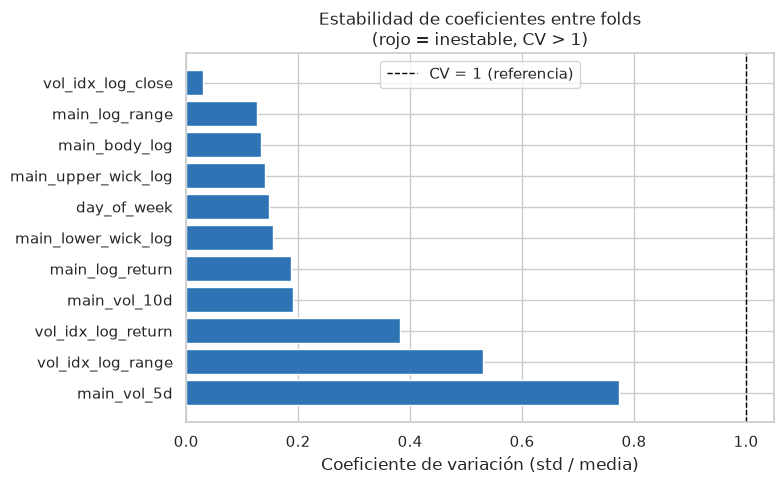

In [30]:
fig, ax = plt.subplots(figsize=(8, 5))
colors = ["#C00000" if v > 1 else "#2E74B5" for v in estabilidad["coef_variacion"]]
ax.barh(estabilidad.index, estabilidad["coef_variacion"], color=colors)
ax.axvline(1, color="black", linestyle="--", linewidth=1, label="CV = 1 (referencia)")
ax.set_xlabel("Coeficiente de variación (std / media)")
ax.set_title("Estabilidad de coeficientes entre folds\n(rojo = inestable, CV > 1)")
ax.legend()
plt.tight_layout()
plt.show()


## Resumen de las 5 pruebas — Ridge

| Prueba | Qué mirar | ¿Hay señal de overfitting? |
|---|---|---|
| 1 — Train vs Test | Gap de RMSE, MAE y R² simultáneamente | |
| 2 — Por régimen | Gap específicamente en "Crisis" | |
| 3 — Curva de validación | ¿El alpha elegido está cerca del mínimo de la curva de test? | |
| 4 — Walk-Forward | ¿La brecha es consistente entre folds o la domina uno solo? | |
| 5 — Coeficientes por fold | ¿Hay variables con CV > 1? | |

Compara esta tabla contra la misma tabla del notebook de GradientBoosting
(y la de RandomForest) antes de decidir qué modelo pasa a la Fase 4 del
plan del ML Service (compuerta de validación antes de promover a
producción).
